In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
from upsetplot import UpSet, from_indicators
import seaborn as sns
from scipy.stats import skew, kurtosis
import scipy.stats as stats
import numpy as np


In [2]:
hdl = pd.read_csv("/home/maria/git/SOROLLA/Results/hdl_genetic_correlation.csv")
ref = pd.read_csv("/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv")

In [4]:
# Review missing values 
hdl.isnull().sum()

SNP_rm_GWAS1_Nmiss      0
SNP_rm_GWAS2_Nmiss      0
SNP_RP_GWAS1_TOTAL      0
SNP_RP_GWAS1_PERC       0
SNP_RP_GWAS2_TOTAL      0
SNP_RP_GWAS2_PERC       0
h2_1                   18
h2_1_se                18
h2_2                   18
h2_2_se                18
gcov                   18
gcov_se                18
rg                     18
se                    682
p                     682
output_file            18
output_file_path       18
id_1                    0
label_1                 0
id_2                    0
label_2                 0
dtype: int64

In [5]:
hdl.columns

Index(['SNP_rm_GWAS1_Nmiss', 'SNP_rm_GWAS2_Nmiss', 'SNP_RP_GWAS1_TOTAL',
       'SNP_RP_GWAS1_PERC', 'SNP_RP_GWAS2_TOTAL', 'SNP_RP_GWAS2_PERC', 'h2_1',
       'h2_1_se', 'h2_2', 'h2_2_se', 'gcov', 'gcov_se', 'rg', 'se', 'p',
       'output_file', 'output_file_path', 'id_1', 'label_1', 'id_2',
       'label_2'],
      dtype='object')

In [6]:
ref.columns

Index(['type', 'selection', 'title', 'pubmedId', 'efoTraits', 'disease',
       'disease_subtype', 'label', 'condition_label', 'summaryStatistics',
       'id', 'filename', 'Ancestry', 'ref_genome', 'snp', 'a1', 'a2', 'frq',
       'FRQ_U', 'FRQ_A', 'z', 'b', 'OR', 'se', 'p', 'N_col', 'N_num',
       'Nca_col', 'Nca_val', 'Nco_col', 'Nco_val', 'INFO', 'ignore'],
      dtype='object')

In [7]:
disease_map = ref.set_index('id')['disease'].to_dict()

# Si no existe, crea la columna con valores NaN
hdl['disease_1'] = hdl.get('disease_1', pd.Series([np.nan]*len(hdl)))
hdl['disease_2'] = hdl.get('disease_2', pd.Series([np.nan]*len(hdl)))

# Ahora rellena con el mapeo
hdl['disease_1'] = hdl['disease_1'].fillna(hdl['id_1'].map(disease_map))
hdl['disease_2'] = hdl['disease_2'].fillna(hdl['id_2'].map(disease_map))

In [8]:
pubmedId_map = ref.set_index('id')['pubmedId'].to_dict()

# Si no existe, crea la columna con valores NaN
hdl['pubmedId_1'] = hdl.get('pubmedId_1', pd.Series([np.nan]*len(hdl)))
hdl['pubmedId_2'] = hdl.get('pubmedId_2', pd.Series([np.nan]*len(hdl)))

# Ahora rellena con el mapeo
hdl['pubmedId_1'] = hdl['pubmedId_1'].fillna(hdl['id_1'].map(pubmedId_map))
hdl['pubmedId_2'] = hdl['pubmedId_2'].fillna(hdl['id_2'].map(pubmedId_map))

In [9]:
# What label_1 and label_2 are most represented for missing p values combined
missing_p = hdl[hdl['p'].isnull()]
missing_p_labels = pd.concat([missing_p['label_1'], missing_p['label_2']])
missing_p_labels.value_counts().head(10)

prostate-cancer         114
crc-cancer-3            114
thyroid-cancer          114
parkinsons-1            114
breast-cancer-4         114
multiple-sclerosis-2    114
uterine-fibroid-1        10
uterine-leiomyoma         9
breast-neoplasm-2         9
breast-cancer-1           8
Name: count, dtype: int64

In [10]:
#Make a list of the labels that have more than 50 missing p values
labels_with_missing_p = missing_p_labels.value_counts()
labels_with_missing_p = labels_with_missing_p[labels_with_missing_p > 50].index.tolist()
labels_with_missing_p

['prostate-cancer',
 'crc-cancer-3',
 'thyroid-cancer',
 'parkinsons-1',
 'breast-cancer-4',
 'multiple-sclerosis-2']

In [37]:
hdl["involves_problematic"] = (hdl["label_1"].isin(labels_with_missing_p) | hdl["label_2"].isin(labels_with_missing_p))
missing_p["involves_problematic"] = (missing_p["label_1"].isin(labels_with_missing_p) | missing_p["label_2"].isin(labels_with_missing_p))
missing_p_clean = missing_p[~missing_p["involves_problematic"]]


/tmp/ipykernel_415622/4123137594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_p["involves_problematic"] = (missing_p["label_1"].isin(labels_with_missing_p) | missing_p["label_2"].isin(labels_with_missing_p))


In [18]:
# Total rows hdl
og_len = len(hdl)
#Total rows with p values
computed_len = len(hdl[hdl["p"].notna()])
# Total missing p values
missing_p_len = len(hdl[hdl['p'].isnull()])
# Total missing p values because of issue with datasets
missing_p_involves_problematic = hdl[hdl['p'].isnull() & hdl['involves_problematic']]

print(f"Total rows in hdl: {og_len}")
print(f"Total rows with p values: {computed_len}")
print(f"Total missing p values: {missing_p_len}")
print(f"Missing because of issue with datasets: {len(missing_p_involves_problematic)}")
print(f"Missing because of other issues: {missing_p_len - len(missing_p_involves_problematic)}")

Total rows in hdl: 6555
Total rows with p values: 5873
Total missing p values: 682
Missing because of issue with datasets: 669
Missing because of other issues: 13


### Check why those diseases

115


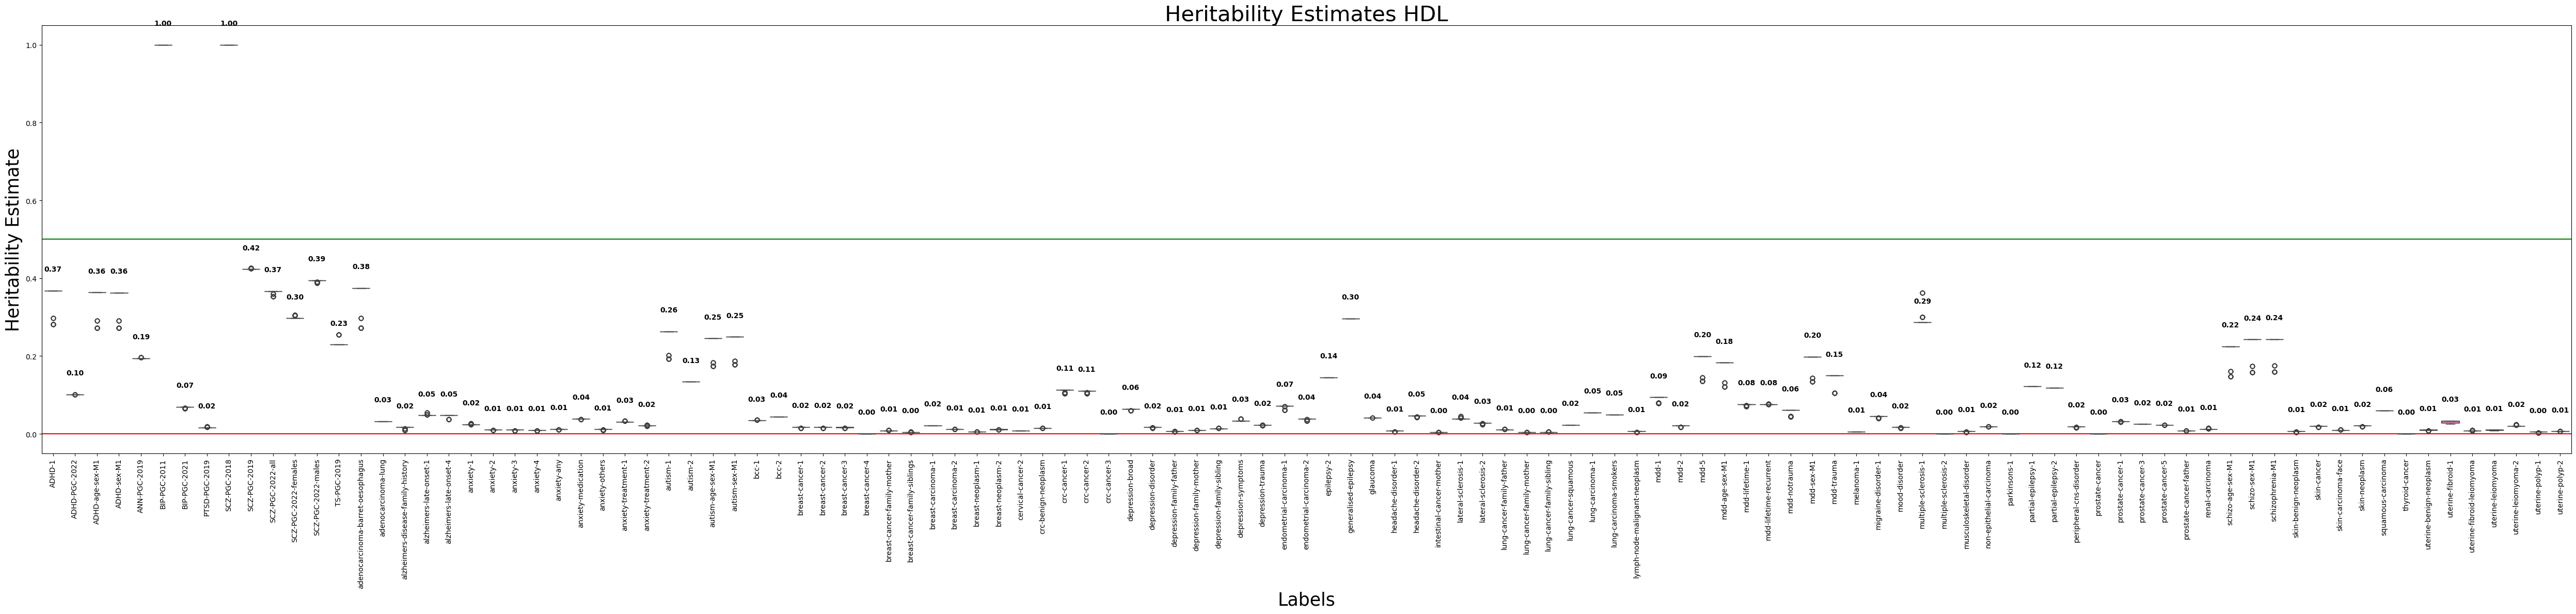

In [21]:
#Get all the heritabilities for each disease considering that each disease might appear in two columns (label_1 and label_2)

unique_labels_heritability_hdl = {}

unique_labels_hdl = pd.unique(hdl[["label_1", "label_2"]].values.ravel("K"))
print(len(unique_labels_hdl))

for label in unique_labels_hdl:
	label_rows_hdl = hdl[(hdl["label_1"]==label)|(hdl["label_2"]==label)]
	h2_1_hdl = label_rows_hdl[label_rows_hdl['label_1'] == label]['h2_1']
	h2_2_hdl = label_rows_hdl[label_rows_hdl['label_2'] == label]['h2_2']
	heritability_hdl  = pd.concat([h2_1_hdl, h2_2_hdl])
	unique_labels_heritability_hdl[label] = heritability_hdl.tolist()

h2df_hdl = pd.DataFrame.from_dict(unique_labels_heritability_hdl, orient="index").T

h2df_hdl = h2df_hdl.reindex(sorted(h2df_hdl.columns), axis=1)


plt.figure(figsize=(50, 12))
sns.boxplot(data=h2df_hdl)
plt.xticks(rotation=90)
plt.axhline(y = 0, color = 'r', linestyle = '-') 
plt.axhline(y = 0.5, color = 'green', linestyle = '-') 
plt.title('Heritability Estimates HDL', fontsize=30)
plt.xlabel('Labels', fontsize=25)
plt.ylabel('Heritability Estimate', fontsize=25)
medians_hdl = h2df_hdl.median().values
for i, col in enumerate(h2df_hdl.columns):
    median_value = h2df_hdl[col].median()
    median_str = f"{median_value:.2f}"
    y_pos = median_value + 0.05
    plt.text(i, y_pos, median_str, ha='center', fontweight='bold', color='black')

plt.tight_layout()

# png_path = "/home/maria/git/SOROLLA/Results/hdl_heritability_boxplot.png"
# jpg_path = "/home/maria/git/SOROLLA/Results/hdl_heritability_boxplot.jpg"
# plt.savefig(png_path, bbox_inches='tight', dpi=300)
# plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

These are the labels with heritability equal or below 0.0 in HDL:
['breast-cancer-4', 'crc-cancer-3', 'multiple-sclerosis-2', 'parkinsons-1', 'prostate-cancer', 'thyroid-cancer']


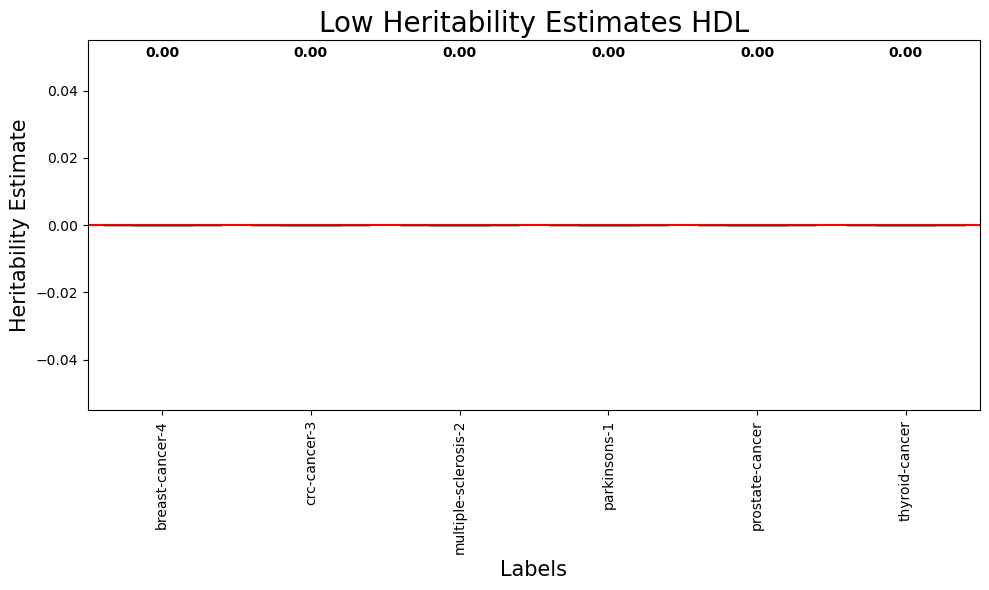

In [22]:
# View what columns have an average heritability equal or below 0.000
low_heritability_hdl = h2df_hdl.columns[h2df_hdl.median() <= 0.0].tolist()
print("These are the labels with heritability equal or below 0.0 in HDL:")
print(low_heritability_hdl)

# Plot just the low heritability on a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=h2df_hdl[low_heritability_hdl])
plt.xticks(rotation=90)
plt.axhline(y = 0, color = 'r', linestyle = '-')
plt.title('Low Heritability Estimates HDL', fontsize=20)
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Heritability Estimate', fontsize=15)
medians_low_hdl = h2df_hdl[low_heritability_hdl].median().values
for i, col in enumerate(h2df_hdl[low_heritability_hdl].columns):
	median_value = h2df_hdl[low_heritability_hdl][col].median()
	median_str = f"{median_value:.2f}"
	y_pos = median_value + 0.05
	plt.text(i, y_pos, median_str, ha='center', fontweight='bold', color='black')
plt.tight_layout()
plt.show()

In [26]:
# Check the pairs that have missing p values but do not involve problematic datasets
missing_p_not_problematic = hdl[hdl['p'].isnull() & ~hdl['involves_problematic']]
missing_p_not_problematic

,SNP_rm_GWAS1_Nmiss,SNP_rm_GWAS2_Nmiss,SNP_RP_GWAS1_TOTAL,SNP_RP_GWAS1_PERC,SNP_RP_GWAS2_TOTAL,SNP_RP_GWAS2_PERC,h2_1,h2_1_se,h2_2,h2_2_se,...,output_file_path,id_1,label_1,id_2,label_2,disease_1,disease_2,pubmedId_1,pubmedId_2,involves_problematic
433,0,0,1029738,1029876,1029867,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90436510,uterine-polyp-1,GCST90044453,uterine-polyp-2,uterus polyps,uterus polyps,30104761.0,34737426.0,False
1367,0,0,1029867,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90041833,breast-neoplasm-2,GCST90435601,breast-cancer-2,breast cancer,breast cancer,34737426.0,30104761.0,False
1410,0,0,1029738,1029876,1029876,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90435666,uterine-benign-neoplasm,GCST009158,uterine-fibroid-1,uterus cancer,uterus cancer,30104761.0,31649266.0,False
1453,0,0,1029738,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90435666,uterine-benign-neoplasm,GCST90435667,uterine-leiomyoma,uterus cancer,uterus cancer,30104761.0,30104761.0,False
2283,0,0,1029738,1029876,1029867,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90435667,uterine-leiomyoma,GCST90042872,uterine-fibroid-leiomyoma,uterus cancer,uterus cancer,30104761.0,34737426.0,False
3111,0,0,1029867,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90041833,breast-neoplasm-2,GCST90435600,breast-cancer-1,breast cancer,breast cancer,34737426.0,30104761.0,False
3352,0,0,1029738,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90435859,depression-disorder,GCST90435857,mood-disorder,major depression disorder,mood disorder,30104761.0,30104761.0,False
4468,0,0,1029876,1029876,1016163,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST009158,uterine-fibroid-1,GCST90239856,uterine-leiomyoma-2,uterus cancer,uterus cancer,31649266.0,36726022.0,False
4726,0,0,1029867,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90041833,breast-neoplasm-2,GCST90435602,breast-cancer-3,breast cancer,breast cancer,34737426.0,30104761.0,False
4735,0,0,1029867,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90041830,non-epithelial-carcinoma,GCST90435597,skin-neoplasm,skin cancer,skin cancer,34737426.0,30104761.0,False


Number of rows with missing p-values and same diseases: 12
Number of rows with missing p-values and different diseases: 1


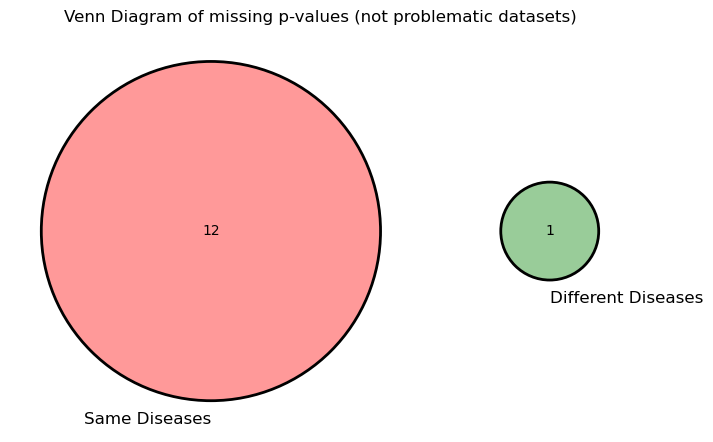

In [28]:
# Plot for same diseases
same_diseases = missing_p_not_problematic[missing_p_not_problematic['disease_1'] == missing_p_not_problematic['disease_2']]
different_diseases = missing_p_not_problematic[missing_p_not_problematic['disease_1'] != missing_p_not_problematic['disease_2']]
print(f"Number of rows with missing p-values and same diseases: {len(same_diseases)}")
print(f"Number of rows with missing p-values and different diseases: {len(different_diseases)}")
# Plot Venn diagram
plt.figure(figsize=(8, 6))
venn2(subsets = (len(same_diseases), len(different_diseases), 0), 
	  set_labels = ('Same Diseases', 'Different Diseases'))			
venn2_circles((len(same_diseases), len(different_diseases), 0))
plt.title("Venn Diagram of missing p-values (not problematic datasets)")
plt.show()	

In [29]:
different_diseases

,SNP_rm_GWAS1_Nmiss,SNP_rm_GWAS2_Nmiss,SNP_RP_GWAS1_TOTAL,SNP_RP_GWAS1_PERC,SNP_RP_GWAS2_TOTAL,SNP_RP_GWAS2_PERC,h2_1,h2_1_se,h2_2,h2_2_se,...,output_file_path,id_1,label_1,id_2,label_2,disease_1,disease_2,pubmedId_1,pubmedId_2,involves_problematic
3352,0,0,1029738,1029876,1029738,1029876,NaN,NaN,NaN,NaN,...,NaN,GCST90435859,depression-disorder,GCST90435857,mood-disorder,major depression disorder,mood disorder,30104761.0,30104761.0,False


Number of rows with missing p-values and same pubmedId: 3
Number of rows with missing p-values and different pubmedId: 10


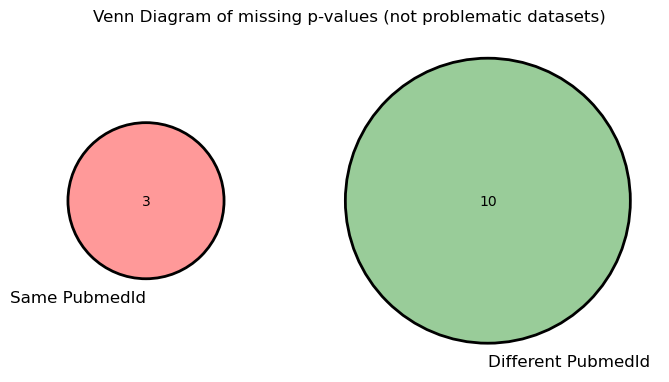

In [30]:
# Plot venn diagram of missing p values considering whether they have the same pubmedId, same label, or same disease
same_pubmedId = missing_p_not_problematic[missing_p_not_problematic['pubmedId_1'] == missing_p_not_problematic['pubmedId_2']]
different_pubmedId = missing_p_not_problematic[missing_p_not_problematic['pubmedId_1'] != missing_p_not_problematic['pubmedId_2']]
print(f"Number of rows with missing p-values and same pubmedId: {len(same_pubmedId)}")
print(f"Number of rows with missing p-values and different pubmedId: {len(different_pubmedId)}")
# Plot Venn diagram
plt.figure(figsize=(8, 6))
venn2(subsets = (len(same_pubmedId), len(different_pubmedId), 0), 
	  set_labels = ('Same PubmedId', 'Different PubmedId'))			
venn2_circles((len(same_pubmedId), len(different_pubmedId), 0))
plt.title("Venn Diagram of missing p-values (not problematic datasets)")
plt.show()


In [31]:
# Create boolean flags for each condition
cond_pubmedId = missing_p_not_problematic['pubmedId_1'] == missing_p_not_problematic['pubmedId_2']
cond_label    = missing_p_not_problematic['label_1']   == missing_p_not_problematic['label_2']
cond_disease  = missing_p_not_problematic['disease_1'] == missing_p_not_problematic['disease_2']

# Now you can count intersections safely
only_pubmedId   = (cond_pubmedId & ~cond_label & ~cond_disease).sum()
only_label      = (~cond_pubmedId & cond_label & ~cond_disease).sum()
only_disease    = (~cond_pubmedId & ~cond_label & cond_disease).sum()
pubmed_label    = (cond_pubmedId & cond_label & ~cond_disease).sum()
pubmed_disease  = (cond_pubmedId & cond_disease & ~cond_label).sum()
label_disease   = (cond_label & cond_disease & ~cond_pubmedId).sum()
all_three       = (cond_pubmedId & cond_label & cond_disease).sum()


/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

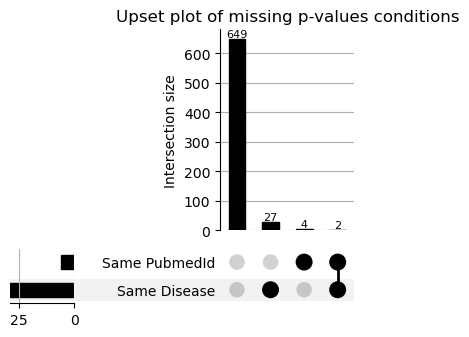

In [35]:
# Boolean flags
cond_pubmedId = missing_p['pubmedId_1'] == missing_p['pubmedId_2']
cond_label    = missing_p['label_1']   == missing_p['label_2']
cond_disease  = missing_p['disease_1'] == missing_p['disease_2']

# Build a DataFrame of indicators
flags = pd.DataFrame({
    'Same PubmedId': cond_pubmedId,
    'Same Label': cond_label,
    'Same Disease': cond_disease
})

# Convert to the format UpSet expects
upset_data_2 = from_indicators(flags, data=pd.Series(1, index=flags.index))

# Plot

# Suponiendo que ya tienes flags y upset_data
upset_2 = UpSet(upset_data_2, subset_size='count')
upset_2.plot()

# Obtener el eje actual (el de las barras verticales)
ax = plt.gca()

# Añadir etiquetas encima de cada barra
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width()/2,
            height,
            str(int(height)),
            ha='center', va='bottom', fontsize=8
        )

plt.title("Upset plot of missing p-values conditions")
plt.show()


/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

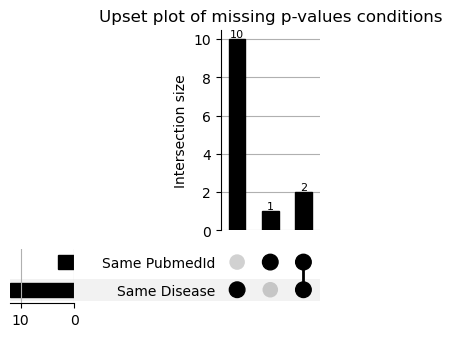

In [38]:
# Boolean flags
cond_pubmedId = missing_p_clean['pubmedId_1'] == missing_p_clean['pubmedId_2']
cond_label    = missing_p_clean['label_1']   == missing_p_clean['label_2']
cond_disease  = missing_p_clean['disease_1'] == missing_p_clean['disease_2']

# Build a DataFrame of indicators
flags = pd.DataFrame({
    'Same PubmedId': cond_pubmedId,
    'Same Label': cond_label,
    'Same Disease': cond_disease
})

# Convert to the format UpSet expects
upset_data_2 = from_indicators(flags, data=pd.Series(1, index=flags.index))

# Plot

# Suponiendo que ya tienes flags y upset_data
upset_2 = UpSet(upset_data_2, subset_size='count')
upset_2.plot()

# Obtener el eje actual (el de las barras verticales)
ax = plt.gca()

# Añadir etiquetas encima de cada barra
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width()/2,
            height,
            str(int(height)),
            ha='center', va='bottom', fontsize=8
        )

plt.title("Upset plot of missing p-values conditions")
plt.show()

/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

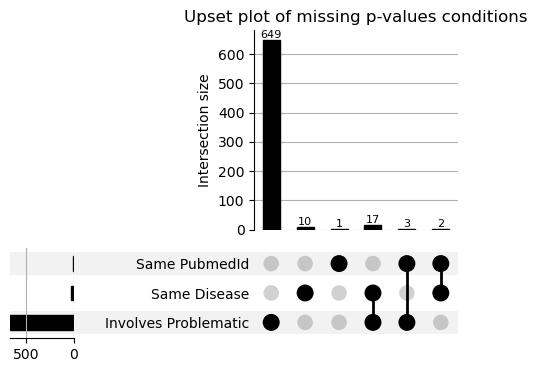

In [39]:

# Suponiendo que ya tienes flags y upset_data
upset = UpSet(upset_data, subset_size='count')
upset.plot()

# Obtener el eje actual (el de las barras verticales)
ax = plt.gca()

# Añadir etiquetas encima de cada barra
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width()/2,
            height,
            str(int(height)),
            ha='center', va='bottom', fontsize=8
        )

plt.title("Upset plot of missing p-values conditions")
plt.show()
